In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from upsetplot import UpSet, from_indicators

In [2]:
a549_df = pd.read_csv('../../output/A549_predictions.csv')
hct116_df = pd.read_csv('../../output/Hct116_predictions.csv')
hepg2_df = pd.read_csv('../../output/Hep2_predictions.csv')
k562_df = pd.read_csv('../../output/K562_predictions.csv')
mcf7_df = pd.read_csv('../../output/MC67_predictions.csv')

threshold = 0.22

## 1. Get Prediction Labels

In [3]:
a549_df['cancer_cell_line'] = 'A549'
hct116_df['cancer_cell_line'] = 'Hct116'
hepg2_df['cancer_cell_line'] = 'Hep-G2'
k562_df['cancer_cell_line'] = 'K562'
mcf7_df['cancer_cell_line'] = 'MCF7'

mcf7_df['transcript_id'] = mcf7_df['transcript_id'].str[0: -2]
mcf7_df

,transcript_id,transcript_position,score,cancer_cell_line
0,ENST00000384629,72,0.05,MCF7
1,ENST00000612463,78,0.12,MCF7
2,ENST00000636484,170,0.07,MCF7
3,ENST00000636484,218,0.01,MCF7
4,ENST00000636484,226,0.00,MCF7
...,...,...,...,...
1252612,ENST00000613012,211,0.07,MCF7
1252613,ENST00000613012,239,0.08,MCF7
1252614,ENST00000613012,373,0.08,MCF7
1252615,ENST00000613012,428,0.06,MCF7


In [4]:
all_df = pd.concat([
    a549_df,
    hct116_df,
    hepg2_df,
    k562_df,
    mcf7_df
])


all_df['pred_label'] = (all_df['score'] >= threshold).astype(int)
all_df = all_df[[
    'cancer_cell_line',
    'transcript_id',
    'transcript_position',
    'pred_label',
    'score'
]]

all_df

,cancer_cell_line,transcript_id,transcript_position,pred_label,score
0,A549,ENST00000418539,108,0,0.06
1,A549,ENST00000418539,139,0,0.05
2,A549,ENST00000383898,75,0,0.05
3,A549,ENST00000610460,78,0,0.10
4,A549,ENST00000619779,78,0,0.10
...,...,...,...,...,...
1252612,MCF7,ENST00000613012,211,0,0.07
1252613,MCF7,ENST00000613012,239,0,0.08
1252614,MCF7,ENST00000613012,373,0,0.08
1252615,MCF7,ENST00000613012,428,0,0.06


## 2. Extract Gene ID

In [5]:
gtf = pd.read_csv(
    '../Homo_sapiens.GRCh38.91.gtf',
    sep='\t',
    comment='#',
    header=None
)

gtf.columns = [
    'seqname', 'source', 'feature', 'start', 'end', 'score',
    'strand', 'frame', 'attribute'
]

C:\Users\janeh\AppData\Local\Temp\ipykernel_19908\2802566722.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv(


In [6]:
def parse_attributes(attr_str):
    attrs = {}
    for kv in re.finditer(r'(\S+) "([^"]+)"', attr_str):
        attrs[kv.group(1)] = kv.group(2)
    return attrs

attributes = gtf['attribute'].apply(parse_attributes)
attributes_df = pd.DataFrame(attributes.tolist())
gtf = pd.concat([gtf.drop(columns=['attribute']), attributes_df], axis=1)

gtf.head(3)

,seqname,source,feature,start,end,score,strand,frame,gene_id,gene_version,...,transcript_source,transcript_biotype,tag,transcript_support_level,exon_number,exon_id,exon_version,ccds_id,protein_id,protein_version
0,1,havana,gene,11869,14409,.,+,.,ENSG00000223972,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,havana,transcript,11869,14409,.,+,.,ENSG00000223972,5,...,havana,processed_transcript,basic,1,NaN,NaN,NaN,NaN,NaN,NaN
2,1,havana,exon,11869,12227,.,+,.,ENSG00000223972,5,...,havana,processed_transcript,basic,1,1,ENSE00002234944,1,NaN,NaN,NaN


## 3. Explore Modified Sites across different cancer cell lines

In [7]:
all_df['transcript_site'] = all_df['transcript_id'].astype(str) + "_" + all_df['transcript_position'].astype(str)
all_df

,cancer_cell_line,transcript_id,transcript_position,pred_label,score,transcript_site
0,A549,ENST00000418539,108,0,0.06,ENST00000418539_108
1,A549,ENST00000418539,139,0,0.05,ENST00000418539_139
2,A549,ENST00000383898,75,0,0.05,ENST00000383898_75
3,A549,ENST00000610460,78,0,0.10,ENST00000610460_78
4,A549,ENST00000619779,78,0,0.10,ENST00000619779_78
...,...,...,...,...,...,...
1252612,MCF7,ENST00000613012,211,0,0.07,ENST00000613012_211
1252613,MCF7,ENST00000613012,239,0,0.08,ENST00000613012_239
1252614,MCF7,ENST00000613012,373,0,0.08,ENST00000613012_373
1252615,MCF7,ENST00000613012,428,0,0.06,ENST00000613012_428


In [8]:
gtf_tx = gtf[gtf['feature'] == 'transcript'].copy()

merged_df = pd.merge(all_df, gtf_tx[['gene_id', 'gene_name', 'transcript_id']], on=['transcript_id'], how='left')

merged_df

,cancer_cell_line,transcript_id,transcript_position,pred_label,score,transcript_site,gene_id,gene_name
0,A549,ENST00000418539,108,0,0.06,ENST00000418539_108,ENSG00000236824,BCYRN1
1,A549,ENST00000418539,139,0,0.05,ENST00000418539_139,ENSG00000236824,BCYRN1
2,A549,ENST00000383898,75,0,0.05,ENST00000383898_75,ENSG00000206625,RNU6-1
3,A549,ENST00000610460,78,0,0.10,ENST00000610460_78,ENSG00000277739,RNA5-8SN5
4,A549,ENST00000619779,78,0,0.10,ENST00000619779_78,ENSG00000273730,RNA5-8SN3
...,...,...,...,...,...,...,...,...
6338106,MCF7,ENST00000613012,211,0,0.07,ENST00000613012_211,ENSG00000276945,AC008498.1
6338107,MCF7,ENST00000613012,239,0,0.08,ENST00000613012_239,ENSG00000276945,AC008498.1
6338108,MCF7,ENST00000613012,373,0,0.08,ENST00000613012_373,ENSG00000276945,AC008498.1
6338109,MCF7,ENST00000613012,428,0,0.06,ENST00000613012_428,ENSG00000276945,AC008498.1


In [9]:
positive_class = all_df.query('pred_label == 1')
positive_class_gene = merged_df.query('pred_label == 1')

In [10]:
all_df.groupby(['cancer_cell_line', 'pred_label']).size().reset_index(name='count')

,cancer_cell_line,pred_label,count
0,A549,0,996669
1,A549,1,12264
2,Hct116,0,1365532
3,Hct116,1,25698
4,Hep-G2,0,1553070
5,Hep-G2,1,27817
6,K562,0,1088820
7,K562,1,15624
8,MCF7,0,1234163
9,MCF7,1,18454


In [11]:
unique_counts = positive_class.groupby('cancer_cell_line')['transcript_id'].nunique().reset_index(name='unique_transcripts')
unique_counts

,cancer_cell_line,unique_transcripts
0,A549,6835
1,Hct116,11231
2,Hep-G2,12496
3,K562,8934
4,MCF7,10151


In [12]:
positive_class_g = positive_class.groupby(['cancer_cell_line', 'transcript_site']).size().reset_index(name='count')
positive_class_p = positive_class_g.pivot(index='transcript_site', columns='cancer_cell_line', values='count')

positive_class_p = positive_class_p.fillna(0)

positive_class_gg = positive_class_gene.groupby(['cancer_cell_line', 'gene_id']).size().reset_index(name='count')
positive_class_pg = positive_class_gg.pivot(index='gene_id', columns='cancer_cell_line', values='count')

positive_class_pg = positive_class_pg.fillna(0)
positive_class_pg

cancer_cell_line,A549,Hct116,Hep-G2,K562,MCF7
gene_id,,,,,
ENSG00000000003,0.0,0.0,3.0,0.0,0.0
ENSG00000000419,1.0,2.0,2.0,2.0,3.0
ENSG00000000971,0.0,0.0,0.0,2.0,0.0
ENSG00000001036,1.0,2.0,2.0,2.0,0.0
ENSG00000001084,1.0,2.0,3.0,0.0,0.0
...,...,...,...,...,...
ENSG00000284668,0.0,0.0,0.0,1.0,0.0
ENSG00000284691,0.0,0.0,4.0,1.0,3.0
ENSG00000284707,0.0,4.0,5.0,4.0,0.0


In [14]:
genes_df = merged_df[['cancer_cell_line', 'gene_id', 'gene_name']].drop_duplicates(['cancer_cell_line','gene_id','gene_name'])
genes_df

,cancer_cell_line,gene_id,gene_name
0,A549,ENSG00000236824,BCYRN1
2,A549,ENSG00000206625,RNU6-1
3,A549,ENSG00000277739,RNA5-8SN5
4,A549,ENSG00000273730,RNA5-8SN3
5,A549,ENSG00000201104,RNU6-11P
...,...,...,...
6338073,MCF7,ENSG00000248635,AC147055.1
6338083,MCF7,ENSG00000227232,WASH7P
6338090,MCF7,ENSG00000279457,FO538757.1
6338101,MCF7,ENSG00000283491,AC017104.5


### Upset Plot to check gene overlap

c:\Users\janeh\anaconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
c:\Users\janeh\anaconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

<Figure size 1000x600 with 0 Axes>

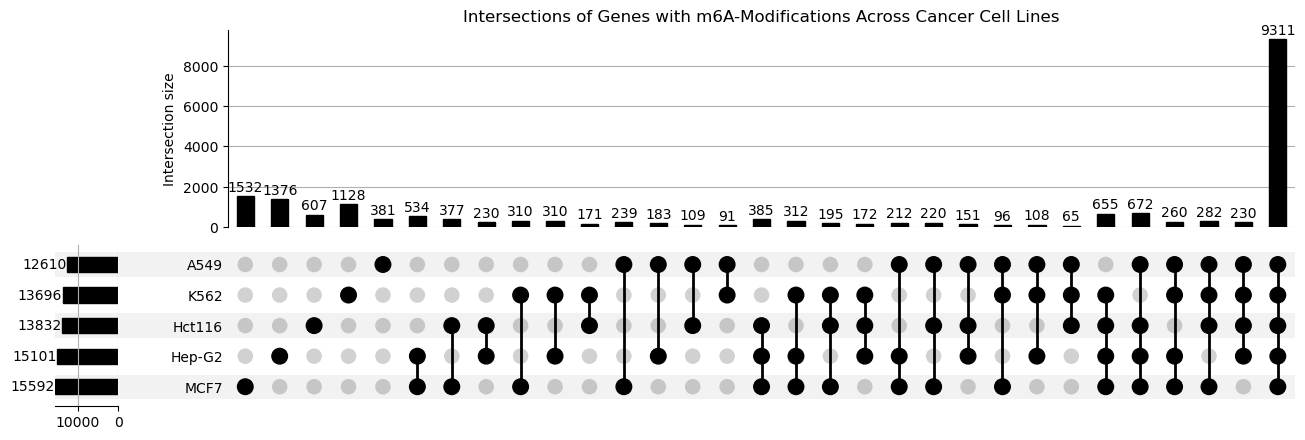

In [15]:
upset_df = genes_df.copy()
binary_matrix = upset_df.groupby(['gene_id', 'cancer_cell_line']).size().unstack(fill_value=0)

# convert counts to True/False
binary_matrix = binary_matrix > 0

# convert to the format needed for UpSet
upset_data = from_indicators(binary_matrix.columns.tolist(), binary_matrix)

plt.figure(figsize=(10,6))
UpSet(upset_data, show_counts=True, sort_by='degree').plot()
plt.title("Intersections of Genes with m6A-Modifications Across Cancer Cell Lines")
plt.show()

### Identify Unique and Common Genes

In [16]:
cell_line_sets = {
    cell_line: set(group['gene_name'])
    for cell_line, group in genes_df.groupby('cancer_cell_line')
}

common_genes = set.intersection(*cell_line_sets.values())
len(common_genes)
common_genes

{'LINC01963',
 'DHRS4',
 'EXOC5',
 'RYK',
 'BUD31',
 'ASCC3',
 'DRG1',
 'DCTPP1',
 'AURKA',
 'TIPARP',
 'MAPKAPK5-AS1',
 'UBXN8',
 'PLRG1',
 'ZNF22',
 'NSUN2',
 'SELENON',
 'STX5',
 'KIN',
 'STRIP1',
 'IKBKB',
 'ZC3H13',
 'INTS11',
 'MTR',
 'RAB11FIP5',
 'TMEM50B',
 'SP110',
 'FAM228B',
 'SPECC1L',
 'MIER2',
 'CPSF3',
 'CUEDC1',
 'ABCA2',
 'HIVEP1',
 'XPO5',
 'TCEA1',
 'AZIN1',
 'MR1',
 'HADH',
 'MAPKAPK3',
 'METTL8',
 'RPL36',
 'COIL',
 'ZIC2',
 'MDM2',
 'ARHGDIA',
 'NRM',
 'C16orf45',
 'WDR74',
 'TRIM8',
 'SH3GLB1',
 'RBBP8',
 'SPATA7',
 'TMEM63A',
 'IQCG',
 'PDXDC1',
 'AFG3L2',
 'TIGD5',
 'PITPNM2',
 'KDM4B',
 'PDCD2',
 'RAB31',
 'ITPA',
 'PACSIN2',
 'DGKD',
 'FUT11',
 'AFAP1',
 'MIPEP',
 'YIPF2',
 'DMTN',
 'YTHDF1',
 'PLPP3',
 'MAP2K4',
 'BCL7A',
 'COA7',
 'ATP6V0B',
 'CEBPB',
 'HMGN1',
 'UTP18',
 'POLR2M',
 'FAM189B',
 'TMEM43',
 'STAM2',
 'YAE1D1',
 'WDR53',
 'BBS9',
 'MSANTD3',
 'ACSL3',
 'CNKSR3',
 'AL390719.1',
 'ERICH6-AS1',
 'PLXND1',
 'SIRT7',
 'FHOD1',
 'SLC30A1',
 'EEF1B2

In [17]:
unique_genes = {
    line: genes - set.union(*(s for l, s in cell_line_sets.items() if l != line))
    for line, genes in cell_line_sets.items()
}

unique_genes

{'A549': {'AC002066.1',
  'AC002094.1',
  'AC002401.4',
  'AC003101.2',
  'AC003984.1',
  'AC004012.1',
  'AC004520.1',
  'AC004552.1',
  'AC004870.2',
  'AC005498.3',
  'AC005736.2',
  'AC006058.1',
  'AC006058.3',
  'AC006445.1',
  'AC006461.1',
  'AC006480.1',
  'AC006518.2',
  'AC006978.2',
  'AC008083.1',
  'AC008536.1',
  'AC008703.1',
  'AC010173.1',
  'AC010326.2',
  'AC011676.1',
  'AC012358.2',
  'AC013472.3',
  'AC015726.1',
  'AC015818.2',
  'AC015819.2',
  'AC017083.1',
  'AC019109.1',
  'AC021086.1',
  'AC022733.2',
  'AC025162.2',
  'AC025524.2',
  'AC026785.1',
  'AC026785.3',
  'AC034231.1',
  'AC064801.1',
  'AC069213.1',
  'AC073109.1',
  'AC073115.2',
  'AC073575.2',
  'AC073610.3',
  'AC073842.2',
  'AC074194.1',
  'AC078802.1',
  'AC082651.1',
  'AC087239.1',
  'AC087386.1',
  'AC090001.1',
  'AC091042.1',
  'AC091173.1',
  'AC092118.1',
  'AC092120.1',
  'AC092140.2',
  'AC092295.2',
  'AC092691.1',
  'AC092757.3',
  'AC093702.1',
  'AC097662.1',
  'AC097724.1',


### Get Oncogenic Signatures

In [18]:
import gseapy as gp

hallmark = gp.get_library_name(organism='Human')
# hallmark contains all available libraries, check if 'Hallmark' is available
genesets = gp.get_library(name='MSigDB_Oncogenic_Signatures', organism='Human')

genesets_df = (
    pd.DataFrame([
        {"gene_name": gene, "cancer_cell_line_gsea": cline}
        for cline, genes in genesets.items()
        for gene in genes
    ])
)

genesets_df

,gene_name,cancer_cell_line_gsea
0,OPN3,GLI1 UP.V1 DN
1,PPIL1,GLI1 UP.V1 DN
2,SPECC1,GLI1 UP.V1 DN
3,YIPF1,GLI1 UP.V1 DN
4,BTBD16,GLI1 UP.V1 DN
...,...,...
31314,TULP2,LEF1 UP.V1 UP
31315,NR3C1,LEF1 UP.V1 UP
31316,CBS,LEF1 UP.V1 UP
31317,SCN5A,LEF1 UP.V1 UP


In [19]:
unique_genes_df = pd.DataFrame([
    {'cancer_cell_line': line, 'gene_name': gene}
    for line, genes in unique_genes.items()
    for gene in genes
])

merged_unique = unique_genes_df.merge(
    genesets_df,
    left_on='gene_name',
    right_on='gene_name',
    how='inner'
)

merged_unique

,cancer_cell_line,gene_name,cancer_cell_line_gsea
0,A549,BCHE,ATM DN.V1 UP
1,A549,BCHE,P53 DN.V1 DN
2,A549,BCHE,MTOR UP.N4.V1 UP
3,A549,CSF2RA,KRAS.600 UP.V1 UP
4,A549,CACNA2D1,VEGF A UP.V1 DN
...,...,...,...
3629,MCF7,PCDHA2,KRAS.PROSTATE UP.V1 UP
3630,MCF7,ACADL,JNK DN.V1 UP
3631,MCF7,ACADL,NOTCH DN.V1 DN
3632,MCF7,ACADL,PDGF UP.V1 DN


In [20]:
merged_unique.query('cancer_cell_line == "Hct116"').groupby('cancer_cell_line_gsea').size().sort_values(ascending=False)

cancer_cell_line_gsea
KRAS.600 UP.V1 UP                9
KRAS.600.LUNG.BREAST UP.V1 UP    8
CTIP DN.V1 DN                    8
KRAS.300 UP.V1 UP                7
KRAS.600 UP.V1 DN                7
                                ..
MEL18 DN.V1 UP                   1
MTOR UP.N4.V1 DN                 1
MTOR UP.N4.V1 UP                 1
NRL DN.V1 DN                     1
YAP1 UP                          1
Length: 146, dtype: int64

### Check Unique Genes for each Cancer Cell Line

,cancer_cell_line,cancer_cell_line_gsea,count
744,MCF7,NFE2L2.V2,19
713,MCF7,KRAS.600 UP.V1 UP,16
712,MCF7,KRAS.600 UP.V1 DN,15
714,MCF7,KRAS.600.LUNG.BREAST UP.V1 DN,15
734,MCF7,MEK UP.V1 DN,12
...,...,...,...
124,A549,RB P130 DN.V1 DN,1
128,A549,SNF5 DN.V1 UP,1
137,A549,TBK1.DF UP,1
138,A549,TBK1.DN.48HRS DN,1


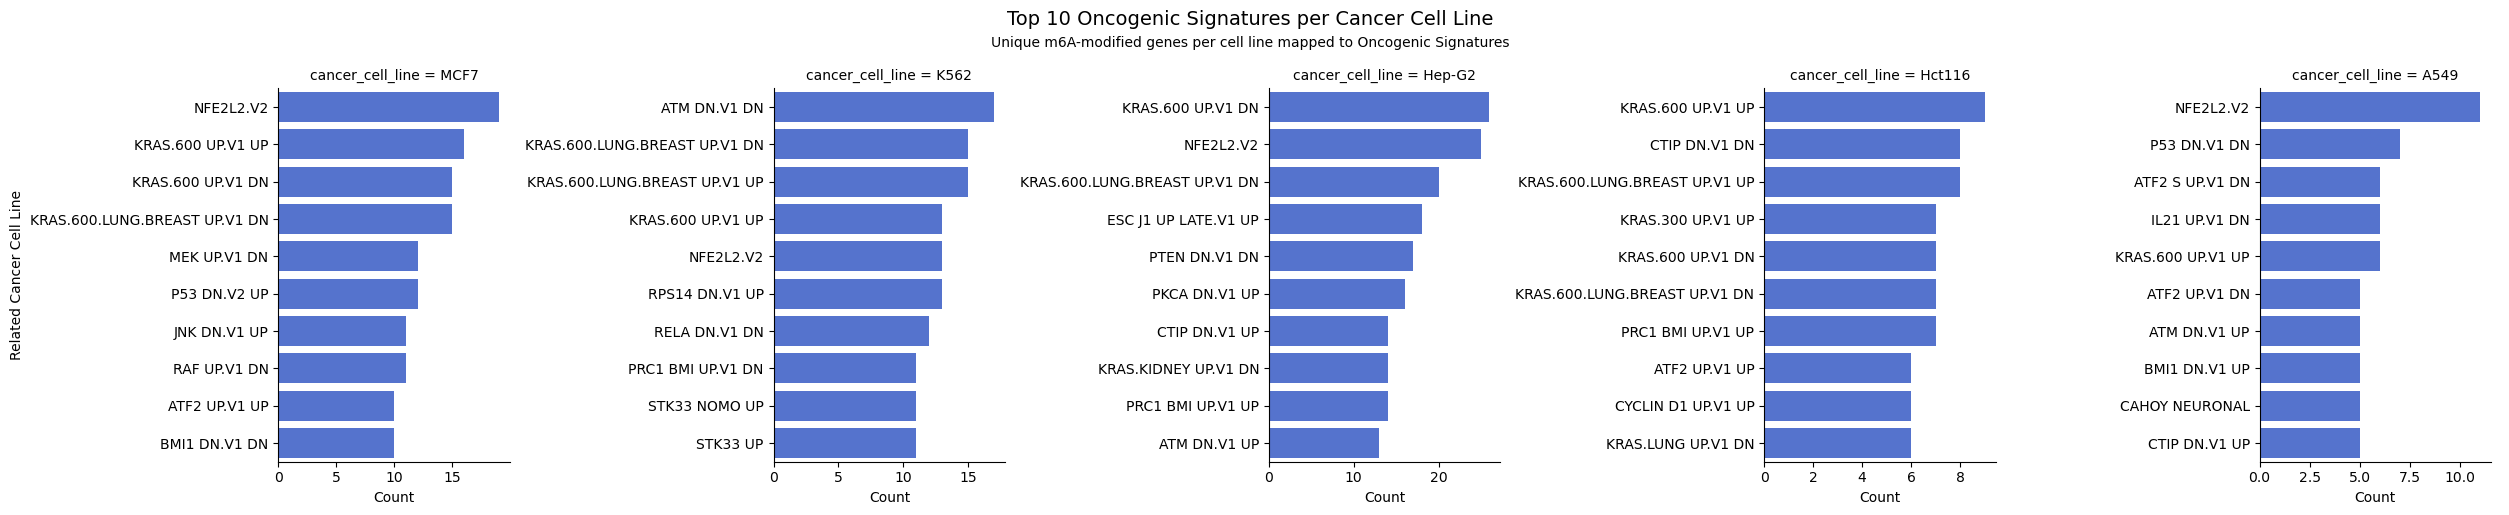

In [29]:
merged_unique_grp = merged_unique.groupby(['cancer_cell_line', 'cancer_cell_line_gsea']).size().reset_index(name='count').sort_values(['cancer_cell_line', 'count'], ascending=False)
display(merged_unique_grp)

merged_unique_grp_n = merged_unique_grp.groupby(['cancer_cell_line']).head(10)

g = sns.catplot(merged_unique_grp_n, y='cancer_cell_line_gsea',
            col='cancer_cell_line', x='count', kind='bar', 
            sharex=False, sharey=False, color='royalblue')

# Main title
g.fig.suptitle("Top 10 Oncogenic Signatures per Cancer Cell Line", fontsize=14, y=1.02)

# Subtitle
g.fig.text(
    0.5, 0.94,
    "Unique m6A-modified genes per cell line mapped to Oncogenic Signatures",
    ha='center',
    va='bottom',
    fontsize=10
)

# Axis labels
g.set_axis_labels("Count", "Related Cancer Cell Line")

plt.tight_layout()
plt.show()

In [22]:
hallmark = gp.get_library_name(organism='Human')
# hallmark contains all available libraries, check if 'Hallmark' is available
genesets = gp.get_library(name='MSigDB_Oncogenic_Signatures', organism='Human')

genesets_df = (
    pd.DataFrame([
        {"gene_name": gene, "cancer_cell_line_gsea": cline}
        for cline, genes in genesets.items()
        for gene in genes
    ])
)

genesets_df

,gene_name,cancer_cell_line_gsea
0,OPN3,GLI1 UP.V1 DN
1,PPIL1,GLI1 UP.V1 DN
2,SPECC1,GLI1 UP.V1 DN
3,YIPF1,GLI1 UP.V1 DN
4,BTBD16,GLI1 UP.V1 DN
...,...,...
31314,TULP2,LEF1 UP.V1 UP
31315,NR3C1,LEF1 UP.V1 UP
31316,CBS,LEF1 UP.V1 UP
31317,SCN5A,LEF1 UP.V1 UP


### Check Common Genes across all cancer cell lines

In [23]:
common_genes_df = pd.DataFrame(list(common_genes), columns=['gene_name'])

merged_common = common_genes_df.merge(
    genesets_df,
    left_on='gene_name',
    right_on='gene_name',
    how='inner'
)

merged_common

,gene_name,cancer_cell_line_gsea
0,EXOC5,TBK1.DF DN
1,RYK,GCNP SHH UP EARLY.V1 UP
2,RYK,GCNP SHH UP LATE.V1 UP
3,RYK,CYCLIN D1 UP.V1 DN
4,BUD31,PTEN DN.V2 UP
...,...,...
11264,MAX,MTOR UP.V1 DN
11265,NKIRAS1,STK33 NOMO UP
11266,NKIRAS1,STK33 UP
11267,HELB,ESC J1 UP LATE.V1 DN


,cancer_cell_line_gsea,count
0,AKT UP MTOR DN.V1 DN,78
1,AKT UP MTOR DN.V1 UP,78
2,AKT UP.V1 DN,63
3,AKT UP.V1 UP,77
4,ALK DN.V1 DN,25
...,...,...
184,VEGF A UP.V1 UP,63
185,WNT UP.V1 DN,54
186,WNT UP.V1 UP,51
187,YAP1 DN,16


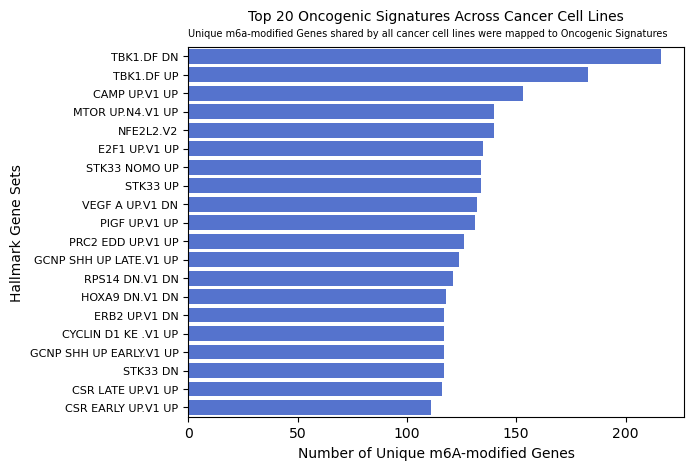

In [24]:
merged_common_grps = merged_common.groupby('cancer_cell_line_gsea').size().reset_index(name='count')
display(merged_common_grps)

sns.barplot(merged_common_grps.sort_values('count', ascending=False).head(20), y='cancer_cell_line_gsea', x='count',
            color='royalblue')

plt.title("Top 20 Oncogenic Signatures Across Cancer Cell Lines", fontsize=10, y=1.05)

# Subtitle
plt.suptitle("Unique m6a-modified Genes shared by all cancer cell lines were mapped to Oncogenic Signatures",
             fontsize=7, y=0.92)  

# Axis labels
plt.xlabel("Number of Unique m6A-modified Genes")
plt.ylabel("Hallmark Gene Sets")
plt.yticks(fontsize=8)

# plt.tight_layout()
plt.show()

In [25]:
merged_common_grps.sort_values('count', ascending=False).head(20)['cancer_cell_line_gsea'].to_list()

['TBK1.DF DN',
 'TBK1.DF UP',
 'CAMP UP.V1 UP',
 'MTOR UP.N4.V1 UP',
 'NFE2L2.V2',
 'E2F1 UP.V1 UP',
 'STK33 NOMO UP',
 'STK33 UP',
 'VEGF A UP.V1 DN',
 'PIGF UP.V1 UP',
 'PRC2 EDD UP.V1 UP',
 'GCNP SHH UP LATE.V1 UP',
 'RPS14 DN.V1 DN',
 'HOXA9 DN.V1 DN',
 'ERB2 UP.V1 DN',
 'CYCLIN D1 KE .V1 UP',
 'GCNP SHH UP EARLY.V1 UP',
 'STK33 DN',
 'CSR LATE UP.V1 UP',
 'CSR EARLY UP.V1 UP']